In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import components.broadcast_components.WZ_models.wz_quant_ANN
import components.broadcast_components.WZ_models.wz_quant_RNN
import components.other_utilities.brent_wz_models
import utilities
import importlib

# ----------------------------------------------------------------
torch.set_float32_matmul_precision('medium')
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
import warnings
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX` has been removed")
warnings.filterwarnings("ignore", message="You defined a `validation_step` but have no `val_dataloader`")
warnings.filterwarnings("ignore", message="Consider setting `persistent_workers=True` in 'train_dataloader'")
warnings.filterwarnings("ignore", message="The 'val_dataloader' does not have")

In [2]:
from components.broadcast_components.broadcasting_process.WZ_broadcast import dict_to_array, data_prep_function
import gzip
import pickle
y=[]
side_info_data_ = []

for i in range(4):
    path_to_file = f'../exp_data/save_grads_per_round/grad_round_{i//2}_worker_{i%2}.pkl.gz'
    with gzip.open(path_to_file, 'rb') as f:
        temp = pickle.load(f)
        y += [dict_to_array(temp).astype(np.float32)]
y = np.sum(y, axis=0)

y+=np.random.normal(0, np.sqrt(1e-6), len(y), ).astype(np.float32)
y_ = y.copy()

y, side_info_data, norm_fact = data_prep_function(y_.copy(), [a.copy() for a in side_info_data_], outlier_rem=False, normalize=True)
side_info_variance, noise_variance = utilities.get_data_var(y, side_info_data)

# y=y[np.abs(y)>0.005*norm_fact]
# y = (np.abs(y)-0.005*norm_fact)*np.sign(y)

temp = np.abs(y)<1.5
removed_y = y[~temp]
y[~temp] = (np.abs(removed_y)-1.5)*np.sign(removed_y)/np.max(np.abs(removed_y))
# plt.figure(figsize=(12, 2))
# plt.hist(y, bins=200, density=True, alpha=0.7)
# plt.hist(removed_y, bins=200, density=True, alpha=0.7)
# plt.ylim(0,3)
# plt.show()
print(sum(1-temp), "#", np.round(sum(1-temp)/len(y)*100, 3), '%')

# ***************************************

# import random
# random.seed(10)
# torch.manual_seed(10)
# np.random.seed(10)
#
# temp = np.random.normal(0, np.sqrt(1), 10_000_000, ).astype(np.float32)
# y_ = temp + np.random.normal(0, np.sqrt(0.01), 10_000_000, ).astype(np.float32)
# side_info_data_ = [temp.copy()]
#
# importlib.reload(utilities)
# y, side_info_data = data_prep_function(y_.copy(), [a.copy() for a in side_info_data_], outlier_rem=True, normalize=False)[:2]
# side_info_variance, noise_variance = utilities.get_data_var(y, side_info_data)

64809 # 0.58 %


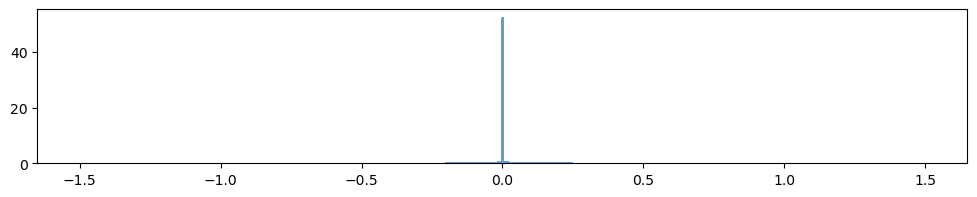

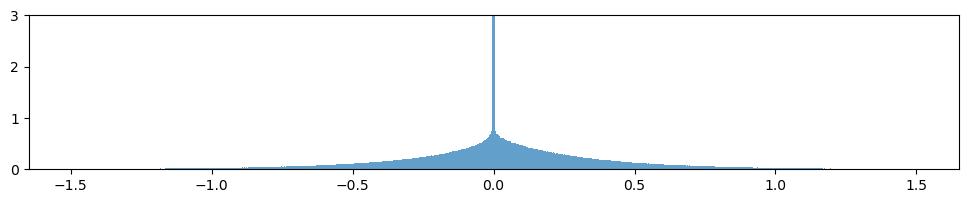

In [3]:
for i in range(2):
    plt.figure(figsize=(12, 2))
    plt.hist(y, alpha=0.7, bins=500*(i+1), density=True)
    if len(side_info_data):
        plt.hist(side_info_data[0], bins=500, alpha=0.7, density=True)
    if i==1:
        plt.ylim(0,3)
        # plt.xlim(-2,2)
    plt.show()

In [4]:
importlib.reload(components.broadcast_components.WZ_models.wz_quant_ANN)
importlib.reload(components.broadcast_components.WZ_models.wz_quant_RNN)
importlib.reload(components.other_utilities.brent_wz_models)
from components.broadcast_components.WZ_models.wz_quant_ANN import WZQuantizer
from components.broadcast_components.WZ_models.wz_quant_RNN import PL_EncoderDecoder_RNN

# seed set
import random
random.seed(10)
torch.manual_seed(10)
np.random.seed(10)

wz_model = PL_EncoderDecoder_RNN(inp_dim=1, side_info_size=0, num_planes=2, bins_per_plane=16, tau=2,
                                 reconst_ld=400, lr=1e-3, marginal=True).to(torch.float32)

wz_model.load_state_dict(torch.load(r'..\..\data\basicRNN_2plane_4bins_state.pt', map_location='cpu'))
# wz_model.load_state_dict(torch.load('chkpnt.pt', map_location='cpu'))
# wz_model.coding_model.load_state_dict(torch.load('checkpoint.pth', map_location='cpu', weights_only=False)['model_state_dict'])

wz_quantizer = WZQuantizer(wz_model, train_sample_size=200_000, count_side_info_data=0, enable_progress_bar=True)

# wz_quantizer.train_model(y, side_info_data, epoch=80, batch_size=10_000)

# # torch.save(wz_model.state_dict(), 'chkpnt.pt')
# torch.save(wz_model.state_dict(), r'..\..\data\basicRNN_2plane_4bins_state.pt')

bins used: 20


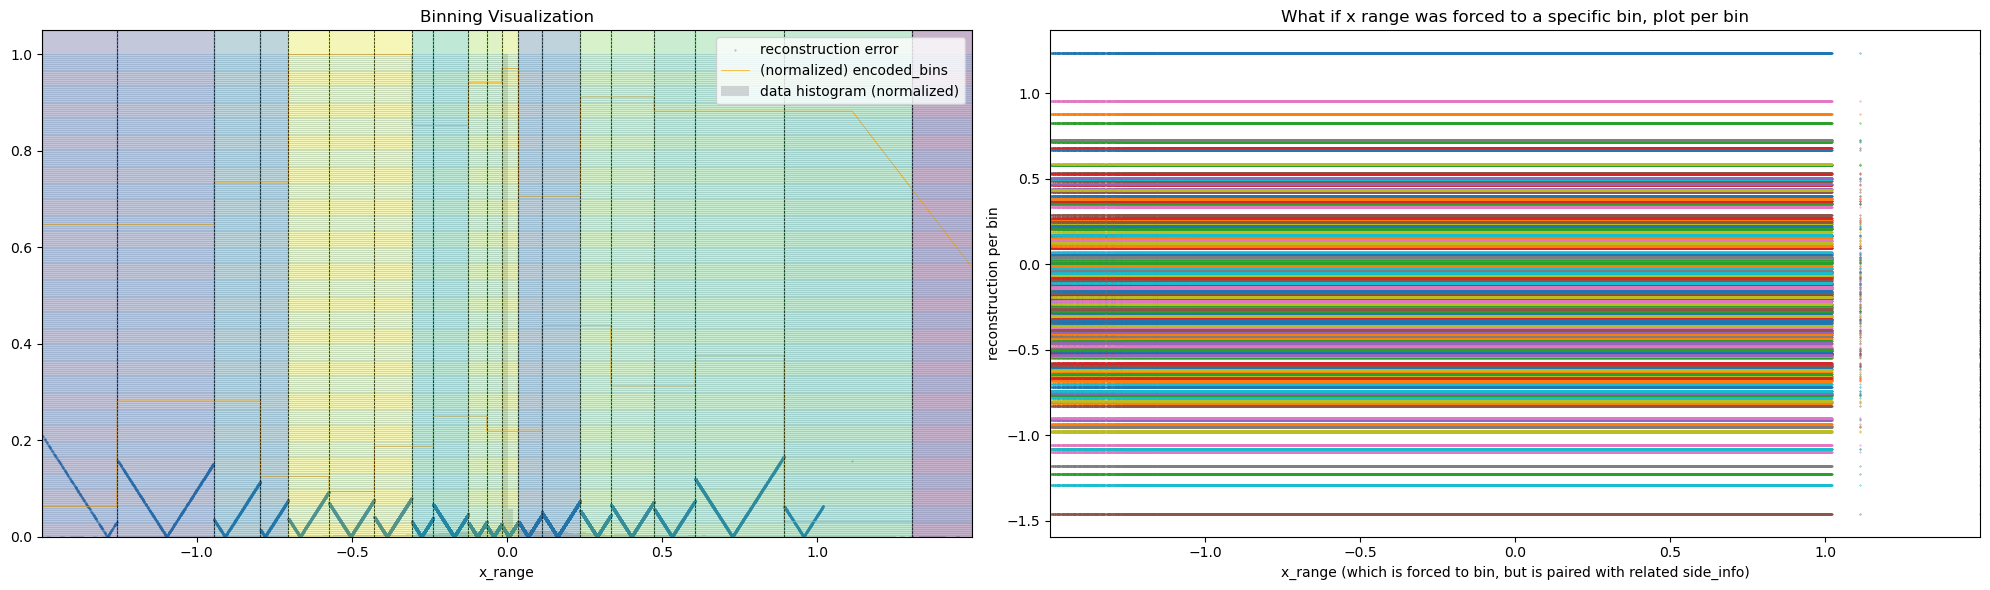

In [6]:
importlib.reload(components.broadcast_components.WZ_models.wz_quant_ANN)
from components.broadcast_components.WZ_models.wz_quant_ANN import plot_bins

temp = np.random.choice(np.arange(len(y)), min(len(y), 200_000), replace=False)
plot_bins(wz_quantizer, y[temp], [a[temp] for a in side_info_data], step_count=min(len(temp), 20_000))

# plot_bins(wz_quantizer, y[temp][np.abs(y[temp])<2.5], [a[temp] for a in side_info_data], step_count=min(len(temp), 10_000))

In [7]:
importlib.reload(components.broadcast_components.WZ_models.wz_quant_ANN)
importlib.reload(components.broadcast_components.WZ_models.wz_quant_RNN)
importlib.reload(utilities)
mse, mspe, real_bit_rate, prior_bit_rate, softcodes_bit_rate = utilities.get_metrics(y, side_info_data, wz_quantizer, )
f'{mse=:0.5f}, {mspe=:0.3f}, {real_bit_rate=:0.3f}, {prior_bit_rate=:0.3f}, {softcodes_bit_rate=:0.3f}'

'mse=0.00065, mspe=0.984, real_bit_rate=3.550, prior_bit_rate=2.902, softcodes_bit_rate=0.073'

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(22, 10))
for i, ax in enumerate(axes):
    bound_x_y = utilities.bound_lines(y, side_info_variance+1e-8, noise_variance, mape_flag=(i==1))
    ax.plot(bound_x_y[0], bound_x_y[1], linewidth=1, label='WZ bound')
    ax.plot(bound_x_y[0], bound_x_y[1]+bound_x_y[2], linewidth=1, linestyle=':', label='Lattice error bound')

    ax.scatter(real_bit_rate, 10 * np.log10(mse if i == 0 else mspe), label='real_bit_rate', s=100, marker='x')
    ax.scatter(prior_bit_rate, 10 * np.log10(mse if i == 0 else mspe), label='prior_bit_rate', s=100, marker='x')

    ax.set_xlabel('Bit Rate (bpp)')
    ax.set_ylabel('Distortion (dB)')
    ax.grid(True)
    ax.legend()
axes[0].set_title('MSE')
axes[1].set_title('mspe')
plt.show()